In [7]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("census/population-time-series-data")

print("Path to dataset files:", path)

100%|██████████| 8.04k/8.04k [00:00<?, ?B/s]

Extracting files...
Path to dataset files: C:\Users\Igor\.cache\kagglehub\datasets\census\population-time-series-data\versions\63


## Датасет из кагла про популяцию людей в сша

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet

df = pd.read_csv(r"C:\Users\Igor\.cache\kagglehub\datasets\census\population-time-series-data\versions\63\POP.csv")


In [15]:
series = df[['date', 'value']].copy()
series.rename(columns={ 'date': 'ds', 'value': 'y' }, inplace=True)
series['ds'] = pd.to_datetime(series['ds'], errors='coerce')

In [16]:
# Отфильтруем строки с некорректными датами
series = series.dropna(subset=['ds'])

# Создаем и обучаем модель
forecaster = Prophet()
forecaster.fit(series)

# Составим датафрейм будущих дат: 10 лет вперед с шагом месяц
horizon_months = 10 * 12
future_dates = forecaster.make_future_dataframe(periods=horizon_months, freq='M')

# Получаем прогноз на будущие месяцы
prediction = forecaster.predict(future_dates)

20:36:44 - cmdstanpy - INFO - Chain [1] start processing
20:36:44 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\Igor\PycharmProjects\pythonProject6\.venv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


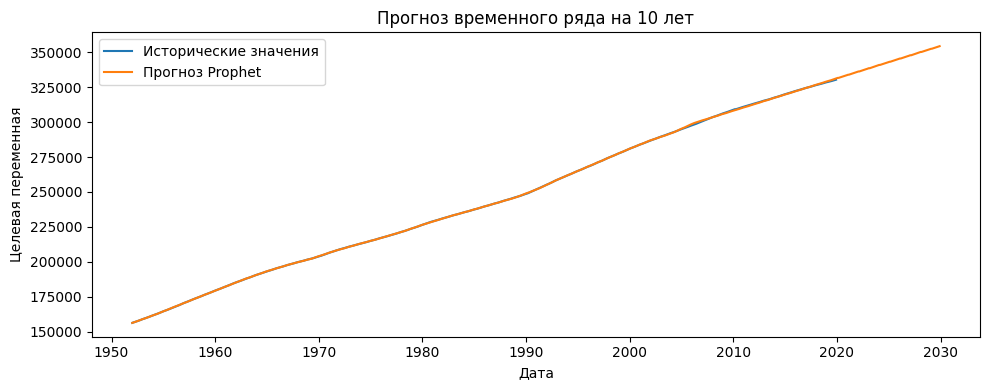

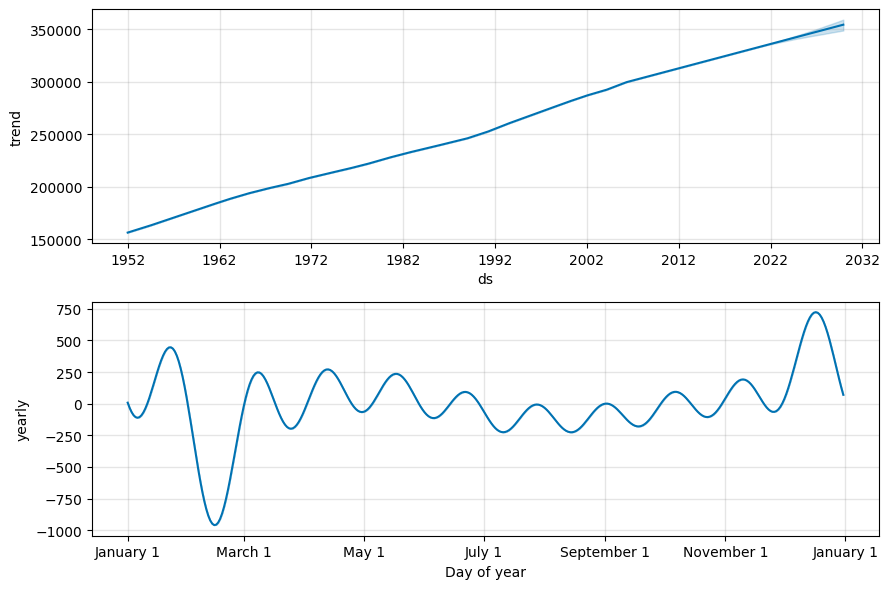

In [17]:
# Визуализируем прогноз
plt.figure(figsize=(10, 4))
plt.plot(series['ds'], series['y'], label='Исторические значения')
plt.plot(prediction['ds'], prediction['yhat'], label='Прогноз Prophet')
plt.title('Прогноз временного ряда на 10 лет')
plt.xlabel('Дата')
plt.ylabel('Целевая переменная')
plt.legend()
plt.tight_layout()
plt.show()

# Отдельно визуализируем компоненты
forecaster.plot_components(prediction)
plt.tight_layout()
plt.show()